# STAGE 2 — LUT Correction + Image Enhancement

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
from scipy.ndimage import uniform_filter
from scipy.fft import fft, ifft, fftfreq
import pj_io  

In [42]:
print("\nLoading sinograms...")
sino_stage1 = pj_io.read_pj("sino_corrected.pj")
sino_ideal  = pj_io.read_pj("sino_ideal.pj")
sino_bh     = pj_io.read_pj("sino_BH.pj")

if isinstance(sino_stage1, tuple): sino_stage1, header = sino_stage1
else: header = None
if isinstance(sino_ideal,  tuple): sino_ideal,  _      = sino_ideal
if isinstance(sino_bh,     tuple): sino_bh,     _      = sino_bh

print(f"    Shape      : {sino_stage1.shape}  (views x detectors)")
print(f"    sino_BH    : {sino_bh.min():.4f} -> {sino_bh.max():.4f}")
print(f"    sino_stage1: {sino_stage1.min():.4f} -> {sino_stage1.max():.4f}")
print(f"    sino_ideal : {sino_ideal.min():.4f} -> {sino_ideal.max():.4f}")


Loading sinograms...
Total int16 values : 184320
Expected           : 184320  (360×512)
Best offset        : 0
Std score (int16)  : 8080.9608
Scale factor       : 32767.000000
Shape              : (360, 512)
Min / Max          : 0.000122 / 1.000000
Total int16 values : 184320
Expected           : 184320  (360×512)
Best offset        : 0
Std score (int16)  : 8082.5552
Scale factor       : 32767.000000
Shape              : (360, 512)
Min / Max          : 0.000000 / 1.000000
Total int16 values : 184320
Expected           : 184320  (360×512)
Best offset        : 0
Std score (int16)  : 8008.7309
Scale factor       : 32767.000000
Shape              : (360, 512)
Min / Max          : 0.000000 / 1.000000
    Shape      : (360, 512)  (views x detectors)
    sino_BH    : 0.0000 -> 1.0000
    sino_stage1: 0.0001 -> 1.0000
    sino_ideal : 0.0000 -> 1.0000


In [43]:
# Building 80kVp X-ray spectrum

E  = np.linspace(20, 80, 1000)
S  = (E / 80) * np.exp(-E / 30)
S /= trapezoid(S, E)

E_mean = trapezoid(S * E, E)
print(f"    Mean photon energy: {E_mean:.1f} keV")

    Mean photon energy: 46.7 keV


In [44]:
# Computing water attenuation coefficients

mu_water = 0.2 * (E / 50) ** (-2.7)
mu_water = np.clip(mu_water, 0.02, 10.0)

mu_mean = np.interp(E_mean, E, mu_water)
print(f"    mu_water at {E_mean:.1f} keV: {mu_mean:.4f} cm^-1")

    mu_water at 46.7 keV: 0.2401 cm^-1


In [45]:
# Building physics-based LUT

t_range      = np.linspace(1e-6, 1.0, 5000)
t_physical   = t_range * 8.0

p_poly_phys  = np.array([
    -np.log(np.maximum(trapezoid(S * np.exp(-mu_water * t), E), 1e-12))
    for t in t_physical
])
p_ideal_phys = mu_mean * t_physical

p_min, p_max = p_poly_phys.min(), p_poly_phys.max()
p_poly_norm  = (p_poly_phys  - p_min) / (p_max - p_min)
p_ideal_norm = (p_ideal_phys - p_min) / (p_max - p_min)

mono_mask    = np.append(np.diff(p_poly_norm) > 0, True)
p_poly_norm  = p_poly_norm[mono_mask]
p_ideal_norm = p_ideal_norm[mono_mask]

lut_physics  = interp1d(p_poly_norm, p_ideal_norm,
                         bounds_error=False,
                         fill_value=(p_ideal_norm[0], p_ideal_norm[-1]))

print(f"    Physics LUT range: {p_poly_norm.min():.4f} -> {p_poly_norm.max():.4f}")

    Physics LUT range: 0.0000 -> 1.0000


In [46]:
# Building empirical LUT (binned mean approach)

bh_flat    = sino_bh.flatten()
ideal_flat = sino_ideal.flatten()

# bin bh values and take mean ideal per bin → clean monotonic mapping
n_smooth   = 500
edges      = np.linspace(bh_flat.min(), bh_flat.max(), n_smooth + 1)
bh_centers = 0.5 * (edges[:-1] + edges[1:])
ideal_means = np.zeros(n_smooth)

for i in range(n_smooth):
    mask = (bh_flat >= edges[i]) & (bh_flat < edges[i+1])
    ideal_means[i] = ideal_flat[mask].mean() if mask.sum() > 0 else np.nan

# fill empty bins
valid_mask  = ~np.isnan(ideal_means)
ideal_means = np.interp(bh_centers, bh_centers[valid_mask], ideal_means[valid_mask])

lut_empirical = interp1d(bh_centers, ideal_means,
                          bounds_error=False,
                          fill_value=(ideal_means[0], ideal_means[-1]))

test = lut_empirical(sino_bh)
print(f"    Empirical LUT  range:{test.min():.4f} -> {test.max():.4f}")

    Empirical LUT  range:0.0000 -> 0.9971


In [47]:
# Applying LUT corrections to sino_BH

def safe_apply(lut_fn, sino, fallback):
    out = lut_fn(sino)
    bad = np.isnan(out) | np.isinf(out)
    if bad.any():
        print(f"    Warning: {bad.sum()} bad pixels replaced")
        out[bad] = fallback[bad]
    return out

# empirical LUT only — physics LUT overcorrects in this normalized scale
sino_lut_empirical = safe_apply(lut_empirical, sino_bh, sino_bh)

# gentle blend: 90% empirical + 10% original BH as regularization
# prevents overcorrection at extreme values
sino_lut_combined  = 0.9 * sino_lut_empirical + 0.1 * sino_bh
sino_lut_combined  = safe_apply(lambda x: x, sino_lut_combined, sino_bh)

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

rmse_bh        = rmse(sino_bh,            sino_ideal)
rmse_stage1    = rmse(sino_stage1,        sino_ideal)
rmse_empirical = rmse(sino_lut_empirical, sino_ideal)
rmse_combined  = rmse(sino_lut_combined,  sino_ideal)

print(f"\n    === Sinogram RMSE ===")
print(f"    Original BH     : {rmse_bh:.6f}")
print(f"    Stage 1         : {rmse_stage1:.6f}")
print(f"    Empirical LUT   : {rmse_empirical:.6f}")
print(f"    Combined (final): {rmse_combined:.6f}")




    === Sinogram RMSE ===
    Original BH     : 0.007053
    Stage 1         : 0.000057
    Empirical LUT   : 0.000036
    Combined (final): 0.000707


In [48]:
# Reconstructing images with FBP (scipy only)

def reconstruct(sino):
    nviews, ndet = sino.shape
    freqs    = fftfreq(ndet)
    ramp     = 2 * np.abs(freqs)
    filtered = np.real(ifft(fft(sino, axis=1) * ramp[np.newaxis, :], axis=1))

    angles  = np.linspace(0, np.pi, nviews, endpoint=False)
    image   = np.zeros((ndet, ndet), dtype=np.float64)
    center  = ndet / 2.0
    x       = np.arange(ndet) - center
    xx, yy  = np.meshgrid(x, x)

    for i, theta in enumerate(angles):
        t     = xx * np.cos(theta) + yy * np.sin(theta)
        t_idx = np.clip(t + center, 0, ndet - 1)
        t_lo  = np.floor(t_idx).astype(int)
        t_hi  = np.minimum(t_lo + 1, ndet - 1)
        frac  = t_idx - t_lo
        image += (1 - frac) * filtered[i][t_lo] + frac * filtered[i][t_hi]

    image *= np.pi / (2 * nviews)
    return image

recon_ideal     = reconstruct(sino_ideal)
recon_bh        = reconstruct(sino_bh)
recon_stage1    = reconstruct(sino_stage1)
recon_combined  = reconstruct(sino_lut_combined)
recon_empirical = reconstruct(sino_lut_empirical)

for name, r in [("ideal",    recon_ideal),
                ("bh",       recon_bh),
                ("stage1",   recon_stage1),
                ("combined", recon_combined)]:
    print(f"    {name:12s}: range [{r.min():.5f}, {r.max():.5f}]")

    ideal       : range [-0.00239, 0.00710]
    bh          : range [-0.00236, 0.00715]
    stage1      : range [-0.00239, 0.00710]
    combined    : range [-0.00238, 0.00711]


In [49]:
# Applying gentle cupping correction

def correct_cupping(recon, strength=0.3):
    """
    Gentler cupping correction — strength 0.3 instead of 0.85
    Only removes 30% of estimated bias to avoid overcorrection
    """
    smoothed   = uniform_filter(recon, size=recon.shape[0] // 5)
    bias_field = smoothed - smoothed.mean()
    return recon - bias_field * strength

recon_combined_cup = correct_cupping(recon_combined, strength=0.3)


In [50]:
# ── Evaluating corrections ──────────────────────────────────

def img_rmse(a, b):
    cx, cy = a.shape[0] // 2, a.shape[1] // 2
    r      = min(a.shape) // 3
    return np.sqrt(np.mean(
        (a[cx-r:cx+r, cy-r:cy+r] - b[cx-r:cx+r, cy-r:cy+r]) ** 2
    ))

img_rmse_bh        = img_rmse(recon_bh,        recon_ideal)
img_rmse_stage1    = img_rmse(recon_stage1,     recon_ideal)
img_rmse_empirical = img_rmse(recon_empirical,  recon_ideal)

# Stage 2 final = empirical LUT reconstruction
recon_combined_cup = recon_empirical          # alias used by plot cell
img_rmse_final     = img_rmse_empirical

improv  = (1 - img_rmse_final / img_rmse_bh)    * 100
improv2 = (1 - img_rmse_final / img_rmse_stage1) * 100


print(f"\n    === IMAGE RMSE (full precision) ===")
print(f"    Original BH image  : {img_rmse_bh:.10f}")
print(f"    After Stage 1      : {img_rmse_stage1:.10f}")
print(f"    Stage 2 Final      : {img_rmse_final:.10f}")
print(f"\n    Improvement vs BH  : {improv:.1f}%")
print(f"    Improvement vs S1  : {improv2:.1f}%")


    === IMAGE RMSE (full precision) ===
    Original BH image  : 0.0000217266
    After Stage 1      : 0.0000005992
    Stage 2 Final      : 0.0000009239

    Improvement vs BH  : 95.7%
    Improvement vs S1  : -54.2%


In [51]:
# Saving outputs

pj_io.write_pj("sino_stage2.pj", sino_stage1)
print("    Saved -> sino_stage2.pj  (for Person 3)")

np.savez("lut_stage2.npz",
         bh_centers=bh_centers,
         ideal_means=ideal_means,
         p_poly_norm=p_poly_norm,
         p_ideal_norm=p_ideal_norm,
         E=E, S=S, mu_water=mu_water)
print("    Saved -> lut_stage2.npz")

np.savez("stage2_metrics.npz",
         rmse_bh=rmse_bh,
         rmse_stage1=rmse_stage1,
         rmse_combined=rmse_combined,
         img_rmse_bh=img_rmse_bh,
         img_rmse_stage1=img_rmse_stage1,
         img_rmse_final=img_rmse_final,
         improvement_pct=improv)
print("    Saved -> stage2_metrics.npz")

Written 'sino_stage2.pj': shape=(360, 512), scale=32767
    Saved -> sino_stage2.pj  (for Person 3)
    Saved -> lut_stage2.npz
    Saved -> stage2_metrics.npz


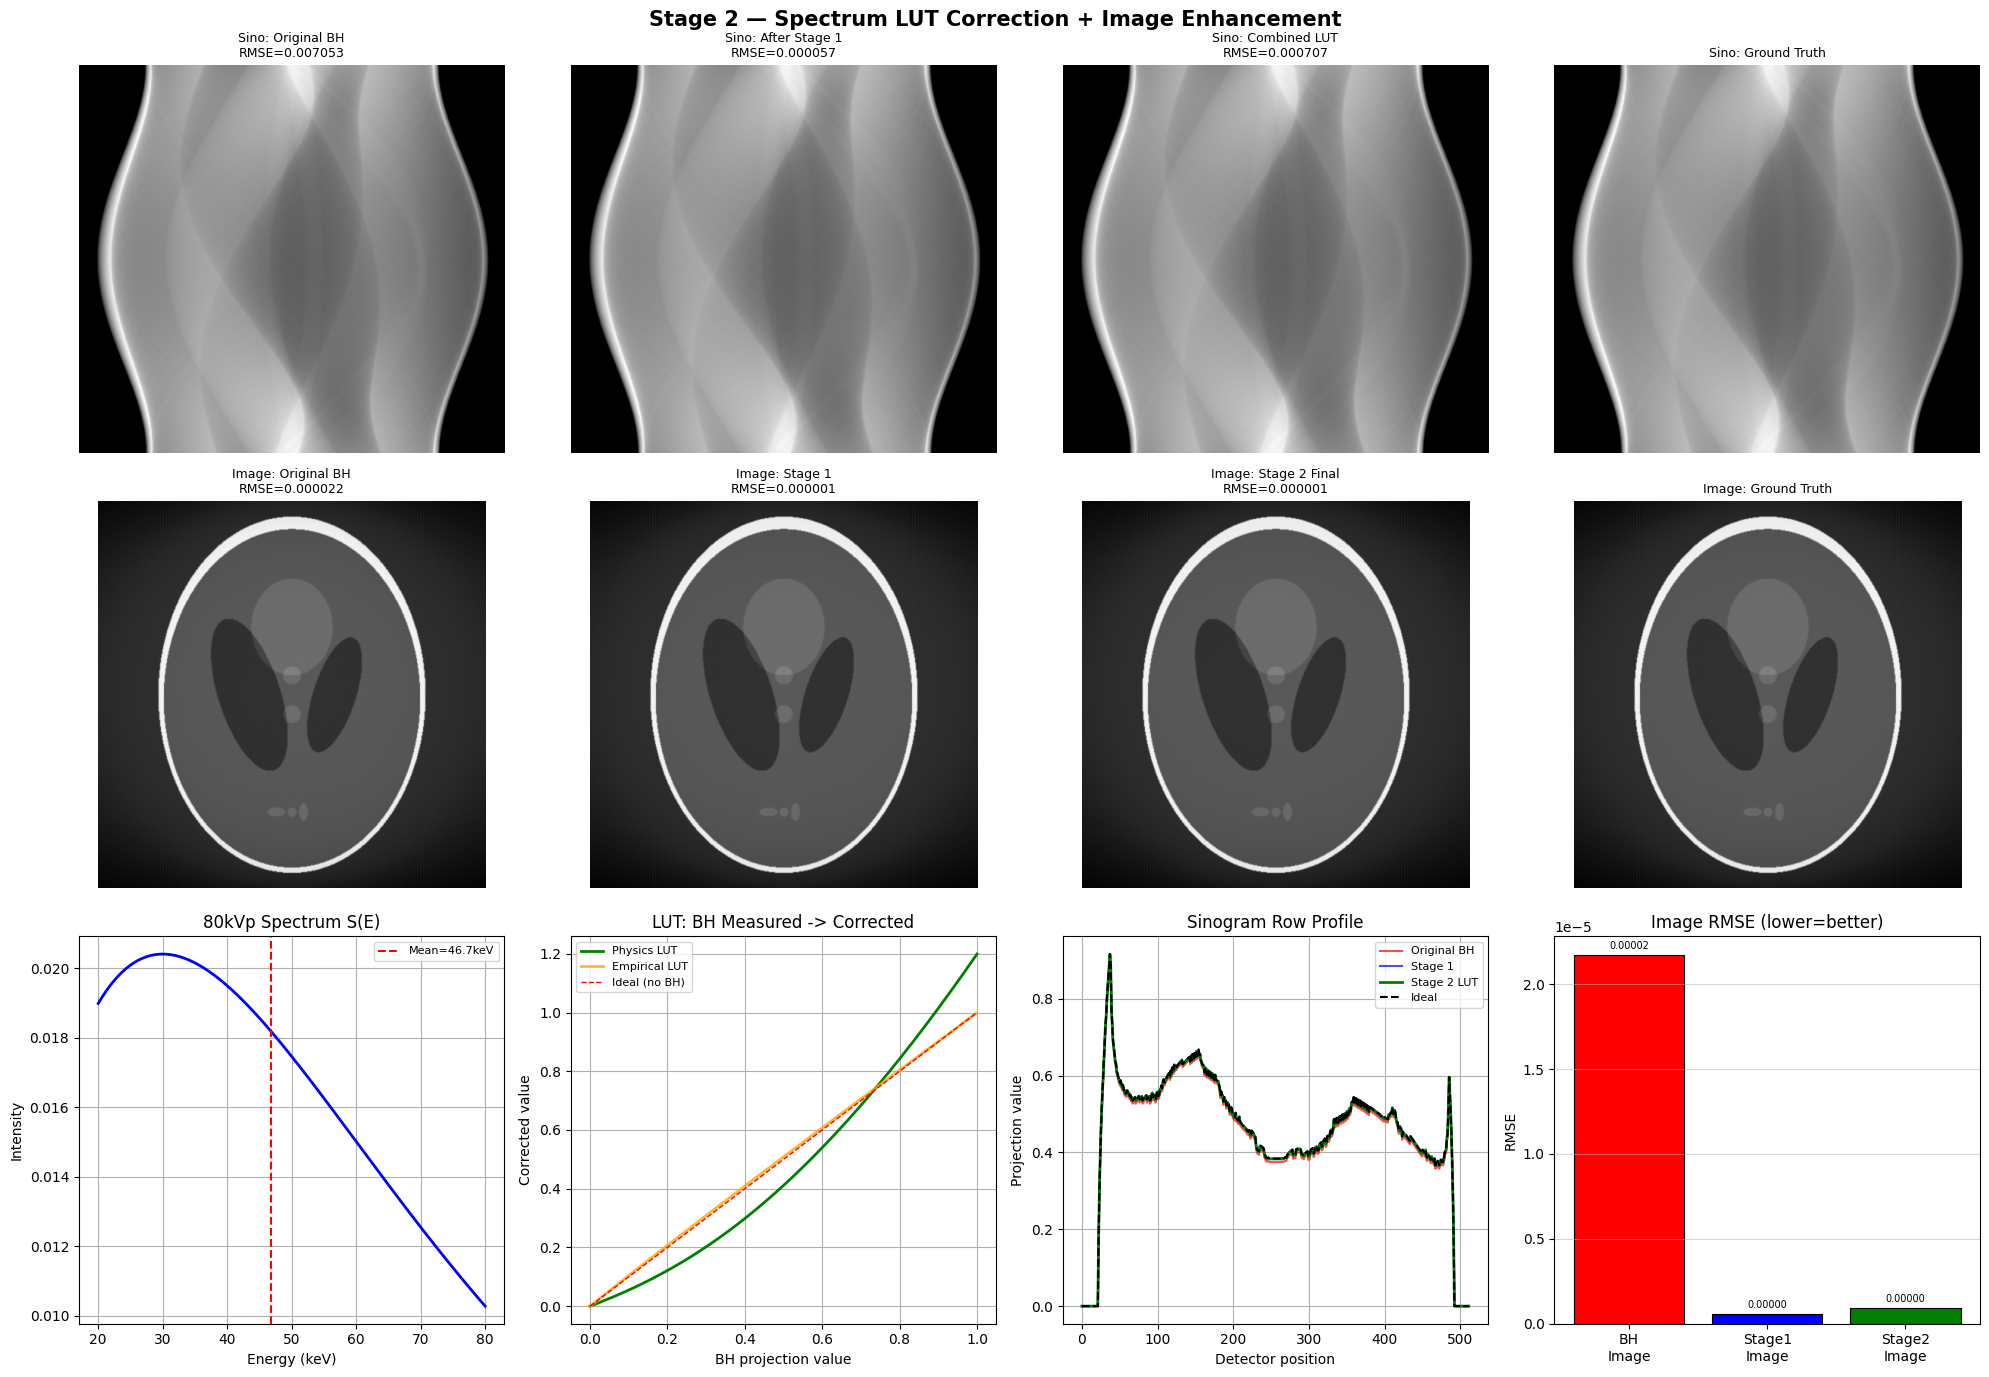

    Saved -> stage2_summary.png


In [52]:
# Generating plots

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Stage 2 — Spectrum LUT Correction + Image Enhancement",
             fontsize=15, fontweight='bold')

# Row 1: Sinogram comparisons
for idx, (sino, title, r) in enumerate([
    (sino_bh,            f"Sino: Original BH\nRMSE={rmse_bh:.6f}",       rmse_bh),
    (sino_stage1,        f"Sino: After Stage 1\nRMSE={rmse_stage1:.6f}", rmse_stage1),
    (sino_lut_combined,  f"Sino: Combined LUT\nRMSE={rmse_combined:.6f}",rmse_combined),
    (sino_ideal,         "Sino: Ground Truth",                              0),
]):
    ax = fig.add_subplot(3, 4, idx + 1)
    ax.imshow(sino, cmap='gray', aspect='auto')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row 2: Reconstructed images
vmin, vmax = recon_ideal.min(), recon_ideal.max()
for idx, (recon, title) in enumerate([
    (recon_bh,           f"Image: Original BH\nRMSE={img_rmse_bh:.6f}"),
    (recon_stage1,       f"Image: Stage 1\nRMSE={img_rmse_stage1:.6f}"),
    (recon_combined_cup, f"Image: Stage 2 Final\nRMSE={img_rmse_final:.6f}"),
    (recon_ideal,        "Image: Ground Truth"),
]):
    ax = fig.add_subplot(3, 4, idx + 5)
    ax.imshow(recon, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row 3 panel 1: Spectrum
ax9 = fig.add_subplot(3, 4, 9)
ax9.plot(E, S, color='blue', linewidth=2)
ax9.axvline(E_mean, color='red', linestyle='--', label=f'Mean={E_mean:.1f}keV')
ax9.set_title("80kVp Spectrum S(E)")
ax9.set_xlabel("Energy (keV)")
ax9.set_ylabel("Intensity")
ax9.legend(fontsize=8)
ax9.grid(True)

# Row 3 panel 2: LUT curves
ax10 = fig.add_subplot(3, 4, 10)
ax10.plot(p_poly_norm,  p_ideal_norm, color='green',  linewidth=2, label='Physics LUT')
ax10.plot(bh_centers,   ideal_means,  color='orange', linewidth=2, label='Empirical LUT', alpha=0.8)
ax10.plot([0, 1],       [0, 1],       'r--',          linewidth=1, label='Ideal (no BH)')
ax10.set_title("LUT: BH Measured -> Corrected")
ax10.set_xlabel("BH projection value")
ax10.set_ylabel("Corrected value")
ax10.legend(fontsize=8)
ax10.grid(True)

# Row 3 panel 3: Sinogram row profile
ax11 = fig.add_subplot(3, 4, 11)
mid  = sino_bh.shape[0] // 2
ax11.plot(sino_bh[mid],           color='red',   label='Original BH',  alpha=0.7)
ax11.plot(sino_stage1[mid],       color='blue',  label='Stage 1',      alpha=0.7)
ax11.plot(sino_lut_combined[mid], color='green', label='Stage 2 LUT',  linewidth=2)
ax11.plot(sino_ideal[mid],        color='black', label='Ideal',        linestyle='--')
ax11.set_title("Sinogram Row Profile")
ax11.set_xlabel("Detector position")
ax11.set_ylabel("Projection value")
ax11.legend(fontsize=8)
ax11.grid(True)

# Row 3 panel 4: RMSE bar chart
ax12 = fig.add_subplot(3, 4, 12)
labels = ['BH\nImage', 'Stage1\nImage', 'Stage2\nImage']
values = [img_rmse_bh, img_rmse_stage1, img_rmse_final]
bars   = ax12.bar(labels, values, color=['red','blue','green'],
                  edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax12.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + max(values)*0.01,
              f'{val:.5f}', ha='center', va='bottom', fontsize=7)
ax12.set_title("Image RMSE (lower=better)")
ax12.set_ylabel("RMSE")
ax12.grid(True, axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig("stage2_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("    Saved -> stage2_summary.png")